# Clasificación de Géneros de Películas

### Parte 1: Exploración de Datos

---

Análisis del corpus de 7,895 películas: distribución de géneros, características numéricas y propiedades del texto de las sinopsis.

In [3]:
# Librerías
import warnings
warnings.filterwarnings('ignore')
import re, ast
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [4]:
# Cargar datos de entrenamiento y prueba
dataTraining = pd.read_csv('data/dataTraining.csv', encoding='UTF-8', index_col=0)
dataTesting  = pd.read_csv('data/dataTesting.csv',  encoding='UTF-8', index_col=0)

print(f'Entrenamiento: {dataTraining.shape} | Test: {dataTesting.shape}')
dataTraining.head(3)

Entrenamiento: (7895, 5) | Test: (3383, 3)


,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2


### 1. Valores faltantes

In [5]:
print('Faltantes — entrenamiento:')
print(dataTraining.isnull().sum())
print('\nFaltantes — test:')
print(dataTesting.isnull().sum())

Faltantes — entrenamiento:
year      0
title     0
plot      0
genres    0
rating    0
dtype: int64

Faltantes — test:
year     0
title    0
plot     0
dtype: int64


### 2. Distribución de géneros

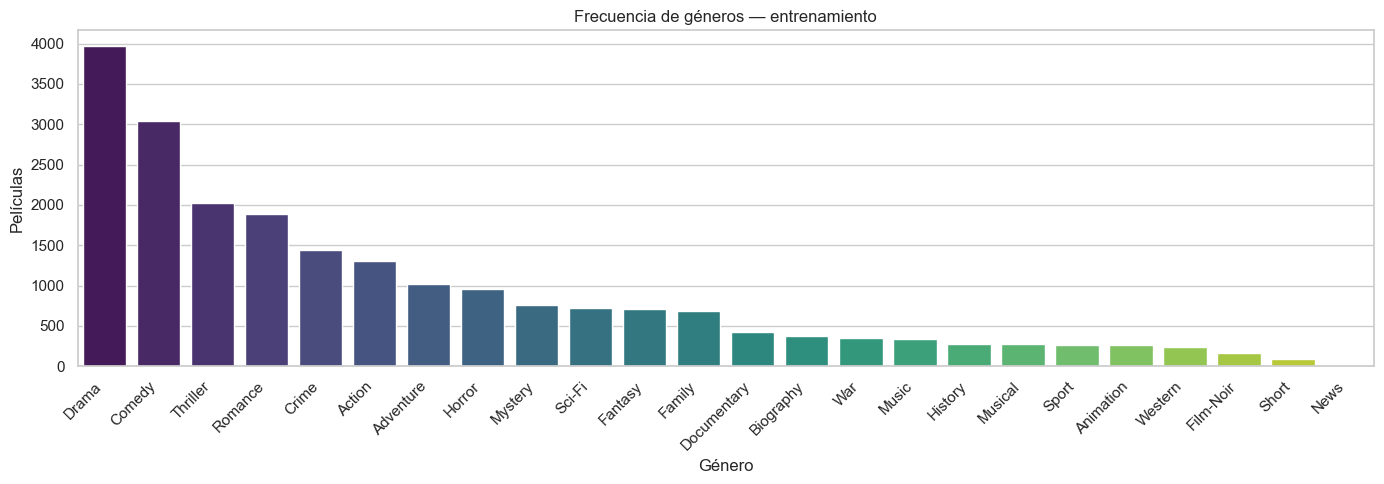

In [6]:
# Convertir columna géneros de string a lista real
vis = dataTraining.copy()
vis['genres'] = vis['genres'].apply(ast.literal_eval)

# Explotar a una fila por género para contar frecuencias
exploded = vis.explode('genres')

plt.figure(figsize=(14, 5))
sns.countplot(data=exploded, x='genres',
              order=exploded['genres'].value_counts().index,
              palette='viridis')
plt.title('Frecuencia de géneros — entrenamiento')
plt.xlabel('Género')
plt.ylabel('Películas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Distribución de variables numéricas

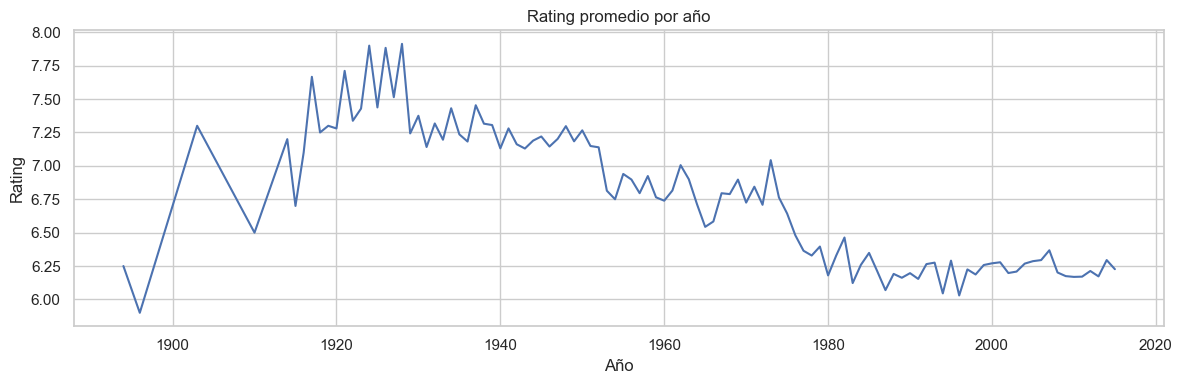

In [7]:
# Rating promedio por año de estreno
rating_año = vis.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=rating_año, x='year', y='rating')
plt.title('Rating promedio por año')
plt.xlabel('Año')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

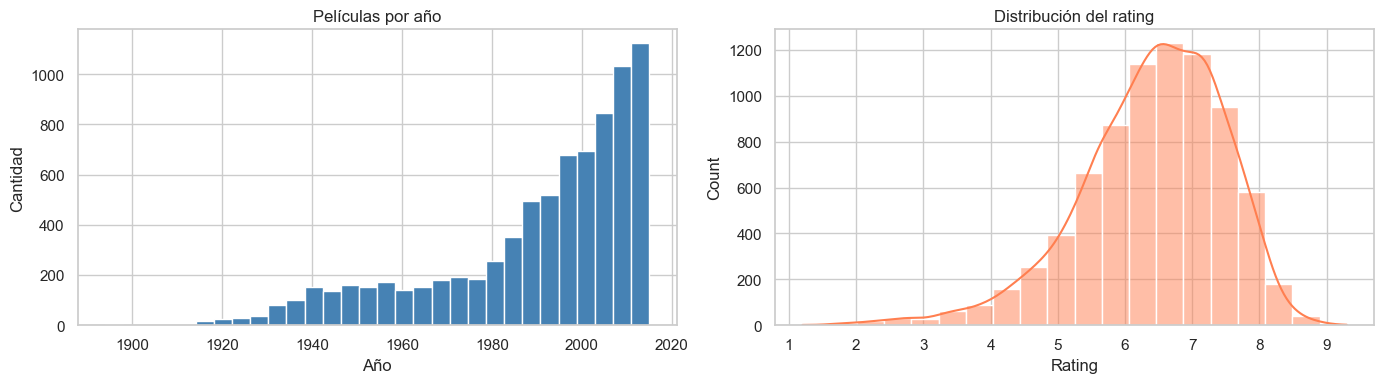

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Películas por año
axes[0].hist(vis['year'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Películas por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

# Distribución del rating
sns.histplot(vis['rating'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución del rating')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

### 4. Estructura multi-etiqueta

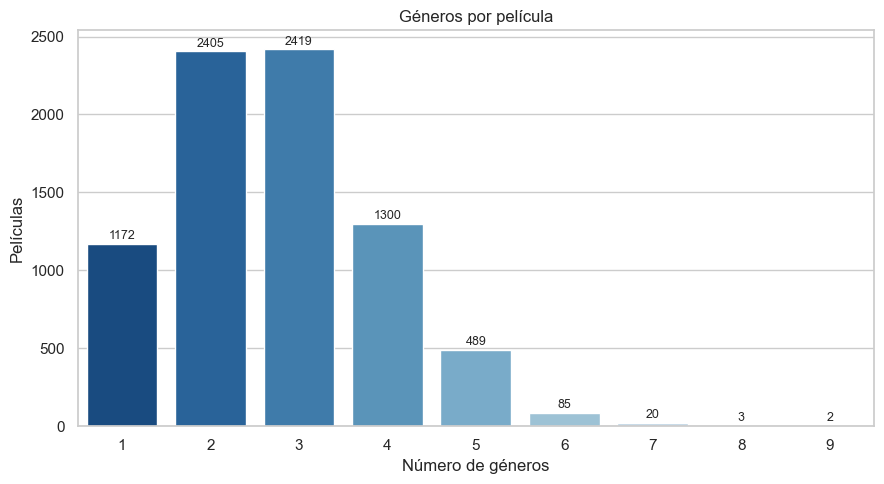

Promedio de géneros por película: 2.73


In [9]:
# Cantidad de géneros asignados por película
genre_counts = vis['genres'].apply(len).value_counts().sort_index()

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Blues_r')
for i, v in enumerate(genre_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.title('Géneros por película')
plt.xlabel('Número de géneros')
plt.ylabel('Películas')
plt.tight_layout()
plt.show()

print(f'Promedio de géneros por película: {vis["genres"].apply(len).mean():.2f}')

### 5. Análisis del texto (sinopsis)

In [10]:
# Tokenización básica para estadísticos de longitud
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

df = vis.copy()
df['tokens']  = df['plot'].apply(tokenize)
df['n_words'] = df['tokens'].apply(len)
df['n_unique'] = df['tokens'].apply(lambda t: len(set(t)))
df['riqueza']  = df['n_unique'] / df['n_words']  # proporción de palabras únicas

print('Longitud de sinopsis (palabras):')
print(df['n_words'].describe(percentiles=[.25, .5, .75, .9]).round(1))

Longitud de sinopsis (palabras):
count    7895.0
mean      126.6
std        84.4
min         1.0
25%        70.0
50%       110.0
75%       161.0
90%       240.0
max      1723.0
Name: n_words, dtype: float64


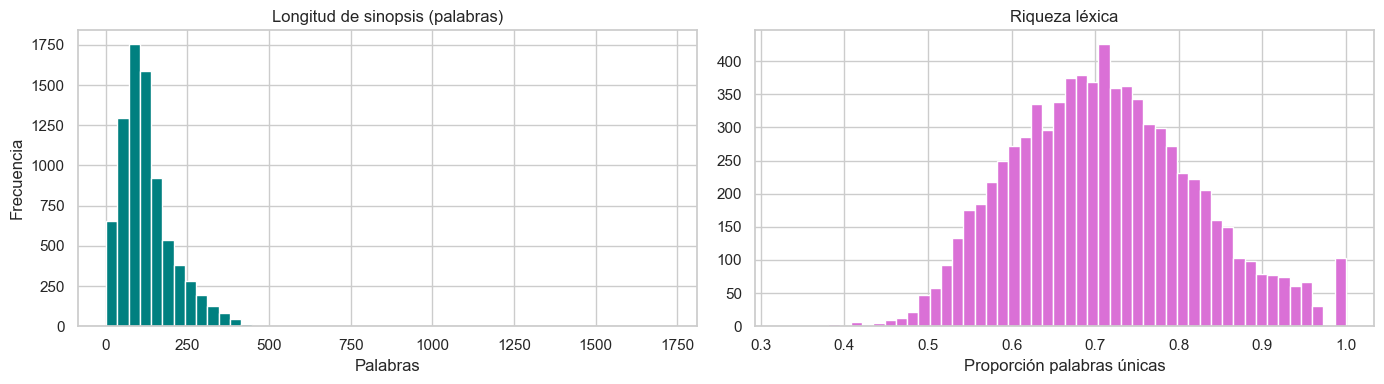

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de longitud de sinopsis
axes[0].hist(df['n_words'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Longitud de sinopsis (palabras)')
axes[0].set_xlabel('Palabras')
axes[0].set_ylabel('Frecuencia')

# Riqueza léxica
axes[1].hist(df['riqueza'], bins=50, color='orchid', edgecolor='white')
axes[1].set_title('Riqueza léxica')
axes[1].set_xlabel('Proporción palabras únicas')

plt.tight_layout()
plt.show()